<a href="https://colab.research.google.com/github/UpendraVishwanathYS/UpendraVishwanathYS/blob/main/MIT_opensource_yolo_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install git+https://github.com/WongKinYiu/YOLO.git

In [ ]:
!git clone https://github.com/WongKinYiu/YOLO.git

Cloning into 'YOLO'...
remote: Enumerating objects: 3697, done.
remote: Counting objects: 100% (1213/1213), done.
remote: Compressing objects: 100% (201/201), done.
remote: Total 3697 (delta 1134), reused 1013 (delta 1012), pack-reused 2484 (from 3)
Receiving objects: 100% (3697/3697), 1.59 MiB | 7.46 MiB/s, done.
Resolving deltas: 100% (2415/2415), done.


In [ ]:
!wget http://images.cocodataset.org/zips/val2017.zip
!unzip val2017.zip -d ./coco
!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!unzip annotations_trainval2017.zip -d ./coco

--2025-07-22 05:31:09--  http://images.cocodataset.org/zips/val2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.217.229.57, 52.217.113.153, 16.15.193.253, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.217.229.57|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 815585330 (778M) [application/zip]
Saving to: ‘val2017.zip.1’

val2017.zip.1       100%[===================>] 777.80M  22.4MB/s    in 37s     

2025-07-22 05:31:47 (20.8 MB/s) - ‘val2017.zip.1’ saved [815585330/815585330]

Archive:  val2017.zip
replace ./coco/val2017/000000212226.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
 extracting: ./coco/val2017/000000212226.jpg  
replace ./coco/val2017/000000231527.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: --2025-07-22 05:32:07--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.216.77.212, 54.231.226.241, 52.217.161.193, ...
Connecti

In [ ]:
from pycocotools.coco import COCO

coco = COCO('/content/coco/annotations/instances_val2017.json')

image_ids = coco.getImgIds()
print(f"Number of images: {len(image_ids)}")

images_with_small_objects = set()
images_with_medium_objects = set()
images_with_large_objects = set()

for ann in coco.loadAnns(coco.getAnnIds()):
    bbox = ann['bbox']
    area = bbox[2] * bbox[3]

    if area < 32**2:
        images_with_small_objects.add(ann['image_id'])
    elif area < 96**2 and area>=32**2:
        images_with_medium_objects.add(ann['image_id'])
    else:
        images_with_large_objects.add(ann['image_id'])

print(f"Number of images with small objects: {len(images_with_small_objects)}")
print(f"Number of images with medium objects: {len(images_with_medium_objects)}")
print(f"Number of images with large objects: {len(images_with_large_objects)}")

loading annotations into memory...
Done (t=0.63s)
creating index...
index created!
Number of images: 5000
Number of images with small objects: 2160
Number of images with medium objects: 3177
Number of images with large objects: 4515


# Inference

/tmp/ipython-input-88-323560312.py:31: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize(config_path=CONFIG_PATH):


[07/21/25 08:59:22] INFO     🚜 Building YOLO                                                            ]8;id=884638;file:///usr/local/lib/python3.11/dist-packages/yolo/model/yolo.py\yolo.py]8;;\:]8;id=871489;file:///usr/local/lib/python3.11/dist-packages/yolo/model/yolo.py#35\35]8;;\

                    INFO       🏗  Building backbone                                                      ]8;id=906629;file:///usr/local/lib/python3.11/dist-packages/yolo/model/yolo.py\yolo.py]8;;\:]8;id=319455;file:///usr/local/lib/python3.11/dist-packages/yolo/model/yolo.py#38\38]8;;\

                    INFO       🏗  Building neck                                                          ]8;id=816550;file:///usr/local/lib/python3.11/dist-packages/yolo/model/yolo.py\yolo.py]8;;\:]8;id=810069;file:///usr/local/lib/python3.11/dist-packages/yolo/model/yolo.py#38\38]8;;\

                    INFO       🏗  Building head                                                          ]8;id=268956;file:///usr/local/lib/python3.11/dist-packages/yolo/model/yolo.py\yolo.py]8;;\:]8;id=464033;file:///usr/local/lib/python3.11/dist-packages/yolo/model/yolo.py#38\38]8;;\

                    INFO       🏗  Building detection                                                     ]8;id=796632;file:///usr/local/lib/python3.11/dist-packages/yolo/model/yolo.py\yolo.py]8;;\:]8;id=48216;file:///usr/local/lib/python3.11/dist-packages/yolo/model/yolo.py#38\38]8;;\

                    INFO       🏗  Building auxiliary                                                     ]8;id=729208;file:///usr/local/lib/python3.11/dist-packages/yolo/model/yolo.py\yolo.py]8;;\:]8;id=412525;file:///usr/local/lib/python3.11/dist-packages/yolo/model/yolo.py#38\38]8;;\

[07/21/25 08:59:23] INFO     ✅ Success load model & weight                                             ]8;id=81186;file:///usr/local/lib/python3.11/dist-packages/yolo/model/yolo.py\yolo.py]8;;\:]8;id=414788;file:///usr/local/lib/python3.11/dist-packages/yolo/model/yolo.py#183\183]8;;\

                    INFO     🈶 Found stride of model [8, 16, 32]                         ]8;id=375776;file:///usr/local/lib/python3.11/dist-packages/yolo/utils/bounding_box_utils.py\bounding_box_utils.py]8;;\:]8;id=256520;file:///usr/local/lib/python3.11/dist-packages/yolo/utils/bounding_box_utils.py#343\343]8;;\

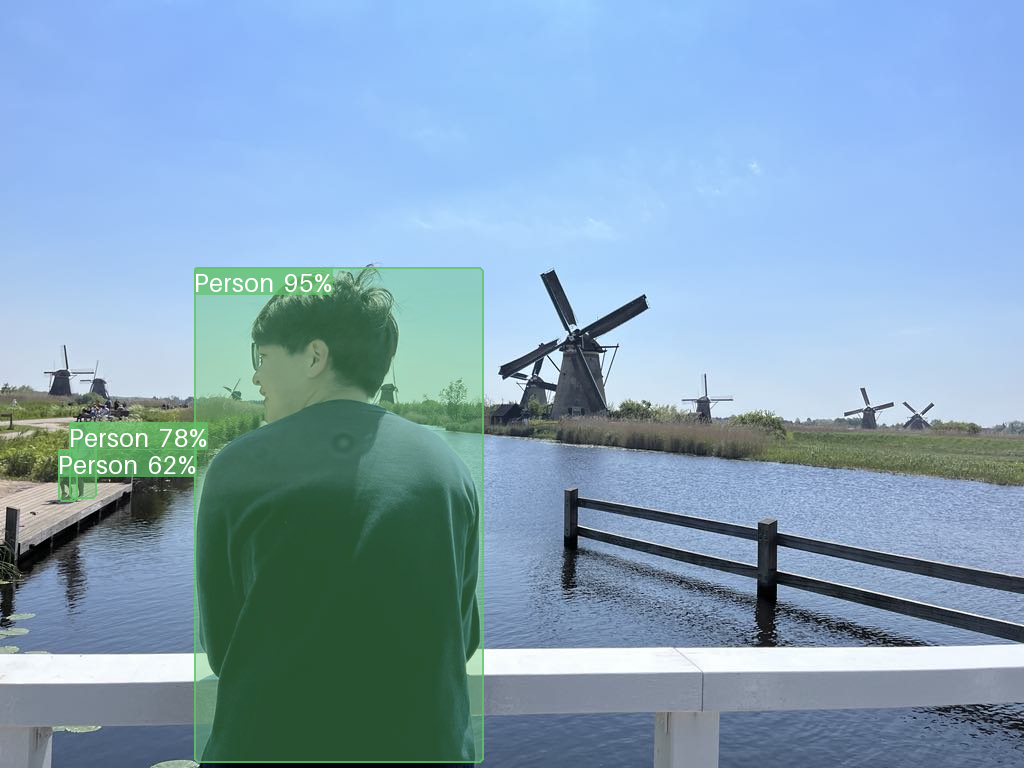

In [ ]:
import sys
from pathlib import Path

import torch
from hydra import compose, initialize
from PIL import Image

project_root = Path('content').resolve().parent
sys.path.append(str(project_root))

from yolo import (
    AugmentationComposer,
    Config,
    create_converter,
    create_model,
    draw_bboxes,
)
from yolo.utils.model_utils import PostProcess

CONFIG_PATH = "../content/YOLO/yolo/config"
CONFIG_NAME = "config"
MODEL = "v9-c"

DEVICE = 'cuda:0'
CLASS_NUM = 80
IMAGE_PATH = '/content/YOLO/demo/images/inference/image.png'

device = torch.device(DEVICE)


with initialize(config_path=CONFIG_PATH):
    cfg: Config = compose(config_name=CONFIG_NAME, overrides=["task=inference", f"task.data.source={IMAGE_PATH}", f"model={MODEL}"])
    model = create_model(cfg.model, class_num=CLASS_NUM).to(device)

    transform = AugmentationComposer([], cfg.image_size)

    converter = create_converter(cfg.model.name, model, cfg.model.anchor, cfg.image_size, device)

    post_proccess = PostProcess(converter, cfg.task.nms)


pil_image = Image.open(IMAGE_PATH)
image, bbox, rev_tensor = transform(pil_image)
image = image.to(device)[None]
rev_tensor = rev_tensor.to(device)[None]

with torch.no_grad():
    predict = model(image)
    pred_bbox = post_proccess(predict, rev_tensor)

draw_bboxes(pil_image, pred_bbox, idx2label=cfg.dataset.class_list)

# Validation

In [ ]:

# required libraries
import sys
from pathlib import Path
import torch
from hydra import compose, initialize

import hydra
from lightning import Trainer

from yolo.config.config import Config
from yolo.tools.solver import InferenceModel, TrainModel, ValidateModel
from yolo.utils.logging_utils import setup


# set root path
project_root = Path('/content/YOLO').resolve().parent
sys.path.append(str(project_root))

# variables and hyperparameters
CONFIG_PATH = "../content/YOLO/yolo/config"
CONFIG_NAME = "config"
MODEL = "v9-c"
DEVICE = 'cuda:0'
CLASS_NUM = 80
use_wandb = False

COCO_IMAGE_DIR = "/content/coco/val2017"
COCO_ANNOTATIONS = "/content/coco/annotations/instances_val2017.json"
device = torch.device(DEVICE)

# setup config:
with initialize(config_path=CONFIG_PATH):
    cfg: Config = compose(

        config_name=CONFIG_NAME,
        overrides=[
            "task=validation",
            f"model={MODEL}",
            f"+task.data.source={COCO_IMAGE_DIR}",
            f"+task.data.annotations={COCO_ANNOTATIONS}",
            f"++use_wandb={use_wandb}"
        ]
    )
callbacks, loggers, save_path = setup(cfg)

# define trainer:
trainer = Trainer(
    accelerator='cuda',
    devices=1,
    max_epochs=getattr(cfg.task, "epoch", None),
    callbacks=callbacks,
    logger=loggers,
    log_every_n_steps=1,
    gradient_clip_val=10,
    gradient_clip_algorithm="value",
    deterministic=True,
    enable_progress_bar=not getattr(cfg, "quite", False),
    default_root_dir=save_path,
)

# benchmarking
model = ValidateModel(cfg)
trainer.validate(model)

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov9c.pt')  # or yolov9e.pt
metrics = model.val(data='coco.yaml')
print(metrics)

Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv9c summary (fused): 156 layers, 25,380,928 parameters, 0 gradients, 102.7 GFLOPs


100%|██████████| 755k/755k [00:00<00:00, 33.4MB/s]

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1527.8±468.5 MB/s, size: 158.8 KB)



val: Scanning /content/datasets/coco/labels/val2017... 4952 images, 48 backgrounds, 0 corrupt: 100%|██████████| 5000/5000 [00:04<00:00, 1049.16it/s]


val: New cache created: /content/datasets/coco/labels/val2017.cache


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 313/313 [02:13<00:00,  2.35it/s]


                   all       5000      36335       0.73      0.634      0.694      0.529
                person       2693      10777      0.825      0.755      0.843      0.635
               bicycle        149        314      0.764      0.564      0.661      0.439
                   car        535       1918       0.77      0.681      0.746      0.528
            motorcycle        159        367      0.795      0.722      0.797      0.557
              airplane         97        143      0.868      0.895       0.93      0.798
                   bus        189        283      0.845      0.806      0.882      0.767
                 train        157        190      0.882      0.889      0.944      0.784
                 truck        250        414      0.696      0.546      0.651      0.486
                  boat        121        424      0.721      0.495      0.573      0.354
         traffic light        191        634      0.729      0.488      0.583      0.332
          fire hydran